In [1]:
# Import various python packages

import iris
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_categorisation as icc
from iris.time import PartialDateTime
import iris.analysis

import xarray as xr

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pandas as pd

import os
import warnings 
import io

import cartopy.io.shapereader as shpreader


from matplotlib.path import Path
import matplotlib.patches as mpatches
import calendar
import matplotlib.colors as colors
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

from scipy.optimize import minimize
from scipy.stats import norm

from scipy.interpolate import PchipInterpolator
from scipy.optimize import differential_evolution

import operator

import pickle
from copy import deepcopy
from pathlib import Path

warnings.filterwarnings('ignore') 

git token: olp_6iyU0oQRp0gcf6tzCR37XCe7ob70qA3iOBPQ

rsync -av /home/users/matt/FutureComparisons/Figures/ /home/users/matt/overleaf/past_future_paper/Figures/
in ~/overleaf/past_future_paper
git add .
git commit -m 'updated figures'
git push


In [2]:
import sys
sys.path.append('..')

from Cube_Functions import *
from Plot_Functions import *
from Climate_Functions import *
from Stats_Functions import *
print('Finished loading libraries and functions')

#clean up namespace
del sys

Finished loading libraries and functions


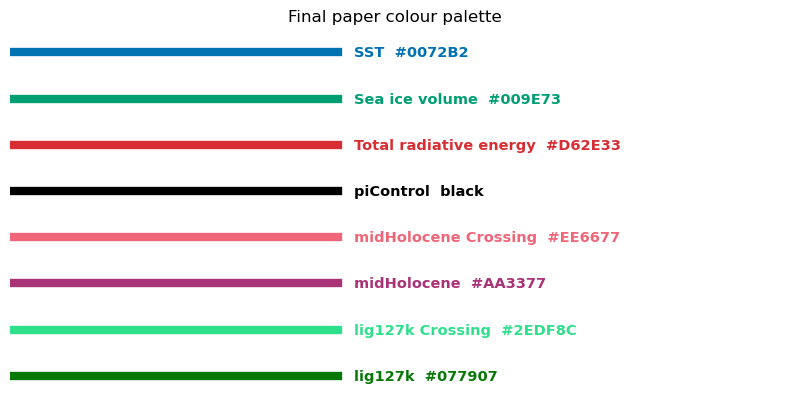

In [ ]:

paper_colours = {
    "lig127k":              "#077907",
    "lig127k Crossing":           "#2EDF8C",
    "midHolocene":              "#AA3377",
    "midHolocene Crossing":           "#EE6677",
    "piControl": "black",
    "Total radiative energy": "#D62E33",  # muted red
    "Sea ice volume":         "#009E73",  # bluish green
    "SST":                    "#0072B2",  # strong blue
}

fig, ax = plt.subplots(figsize=(8, 4.2))

for i, (label, color) in enumerate(paper_colours.items()):
    ax.plot([0, 1], [i, i], color=color, linewidth=6)
    ax.text(
        1.05, i,
        f"{label}  {color}",
        va="center",
        color=color,
        fontsize=10.5,
        fontweight="bold",
    )

ax.set_xlim(0, 2.35)
ax.set_ylim(-0.5, len(paper_colours) - 0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Final paper colour palette")
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.show()

In [4]:
hadgem_path = '/gws/ssde/j25a/bas_palaeoclim/rachel/ARCHER2_regridded/u-ck768/'

hadgem_file = 'regridded_cice_ck768i_1d_18500101-18500201.nc'

hadgem_cubes = iris.load(hadgem_path+hadgem_file)

In [5]:
for i, cube in enumerate(hadgem_cubes):
    print(f'Cube {i}: {cube.name()}')
    print('experiment_id:', cube.attributes.get('experiment_id'))
    print('experiment:', cube.attributes.get('experiment'))
    print('source_id:', cube.attributes.get('source_id'))
    print('variant_label:', cube.attributes.get('variant_label'))
    print()

Cube 0: melt pond fraction of grid cell
experiment_id: None
experiment: None
source_id: None
variant_label: None

Cube 1: grid cell mean ice thickness
experiment_id: None
experiment: None
source_id: None
variant_label: None

Cube 2: ice volume tendency dynamics
experiment_id: None
experiment: None
source_id: None
variant_label: None

Cube 3: ice volume tendency thermo
experiment_id: None
experiment: None
source_id: None
variant_label: None

Cube 4: ice area  (aggregate)
experiment_id: None
experiment: None
source_id: None
variant_label: None



In [20]:
#Primary settings 

models = [
            'ACCESS-ESM1-5',
            'CESM2',
            'IPSL-CM6A-LR',
            'MIROC-ES2L',
            'NESM3',
            ]





control = 'piControl'
transient = '1pctCO2'
paleo = 'lig127k' #Analysis is run on paleo
paleo2 = 'midHolocene' #set paleo2 to None to not use it, or set it to a string to use it (e.g. 'midHolocene'). Analysis still runs on paleo, but paleo2 data is loaded for comparison and plotting.

experiments = [control, transient, paleo, paleo2]

root_path = '/gws/nopw/j04/pmip4_vol1/public/matt/data/'


ice_vars = ['siconc', 'sithick']

experiment_list = [control,
                   paleo,
                   f'{paleo} Crossing',
                   paleo2,
                   f'{paleo2} Crossing',
]

# Climatology plot settings
x = np.array([15, 45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345])
m = np.arange(12)
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

In [7]:
#Define region

con = iris.Constraint(latitude=lambda lat: 60 <= lat <= 90)

time_con = iris.Constraint(year=lambda y:np.logical_and(y>=2035,y<2045))  #time_constraint. Not used anywhere yet.

ocean_shp_reader = shpreader.Reader(shpreader.natural_earth(resolution="110m", category="physical", name="ocean"))
ocean_list = []
for ocean in ocean_shp_reader.records():
    ocean_list.append(ocean.geometry)
ocean_shp = ocean_list[1]

shape = ocean_shp

In [8]:
#Crossing years defined from main script

crossing_dict = {
    'ACCESS-ESM1-5': 65,
    'CESM2': 57,
    'IPSL-CM6A-LR': 52,
    'MIROC-ES2L': 34,
    'NESM3': 34,
    }

crossing2_dict = {
    'ACCESS-ESM1-5': 23,
    'CESM2': 23,
    'IPSL-CM6A-LR': 11,
    'MIROC-ES2L': 20,
    'NESM3': 10,
    }

In [ ]:
######NEED TO CHANGE THIS TO GET THE CROSSING POINT
######EITHER TAKE IT FROM THE PREVIOUS CODE / TABLE and hard code it, or write a function to calculate it from the data.


var = 'siconc'

window = 10
half_window = window / 2

exp_siconc_dict = {}
exp_sia_dict = {}
for experiment in experiments:


    print(f'Processing {experiment}', end='...')

    if experiment == transient:
        model_siconc_dict = {}
        model_sia_dict = {}
        mmm_cube = None
        for model in models:
            print(f'{model}', end='...')
            path = create_path(model, experiment, var, root_path, regrid_label='cdo')
            total_cube = get_cube(path, var, con, shape=shape)
            years_coord = total_cube.coord('year').points
            unique_years = np.unique(years_coord)
            crossing_year = unique_years[crossing_dict[model]]
            year_constraint = iris.Constraint(
                year=lambda y: crossing_year - half_window <= y < crossing_year + half_window
                )
            cube = total_cube.extract(year_constraint)            
            climatology_cube = cube.aggregated_by('month', iris.analysis.MEAN)
            model_sia_dict[model] = get_monthly_data(cube)
            model_siconc_dict[model] = climatology_cube
            if mmm_cube is None:
                mmm_cube = climatology_cube.copy()
            else:
                mmm_cube.data += climatology_cube.data
        print('Done.')
        mmm_cube.data /= len(models)
        model_siconc_dict['MMM'] = mmm_cube
        exp_siconc_dict[f'{paleo} Crossing'] = model_siconc_dict
        exp_sia_dict[f'{paleo} Crossing'] = model_sia_dict

        model_siconc_dict = {}
        model_sia_dict = {}
        mmm_cube = None
        for model in models:
            print(f'{model}', end='...')
            path = create_path(model, experiment, var, root_path, regrid_label='cdo')
            total_cube = get_cube(path, var, con, shape=shape)
            years_coord = total_cube.coord('year').points
            unique_years = np.unique(years_coord)
            crossing_year = unique_years[crossing2_dict[model]]
            year_constraint = iris.Constraint(
                year=lambda y: crossing_year - half_window <= y < crossing_year + half_window
                )
            cube = total_cube.extract(year_constraint)            
            climatology_cube = cube.aggregated_by('month', iris.analysis.MEAN)
            model_sia_dict[model] = get_monthly_data(cube)
            model_siconc_dict[model] = climatology_cube
            if mmm_cube is None:
                mmm_cube = climatology_cube.copy()
            else:
                mmm_cube.data += climatology_cube.data
        print('Done.')
        mmm_cube.data /= len(models)
        model_siconc_dict['MMM'] = mmm_cube
        exp_siconc_dict[f'{paleo2} Crossing'] = model_siconc_dict
        exp_sia_dict[f'{paleo2} Crossing'] = model_sia_dict

    else:
        model_siconc_dict = {}
        model_sia_dict = {}
        mmm_cube = None
        for model in models:
            print(f'{model}', end='...')
            path = create_path(model, experiment, var, root_path, regrid_label='cdo')
            cube = get_cube(path, var, con, shape=shape)
            climatology_cube = cube.aggregated_by('month', iris.analysis.MEAN)
            model_sia_dict[model] = get_monthly_data(cube)
            model_siconc_dict[model] = climatology_cube
            if mmm_cube is None:
                mmm_cube = climatology_cube.copy()
            else:
                mmm_cube.data += climatology_cube.data
        print('Done.')
        mmm_cube.data /= len(models)
        model_siconc_dict['MMM'] = mmm_cube
        exp_siconc_dict[experiment] = model_siconc_dict
        exp_sia_dict[experiment] = model_sia_dict




Processing piControl...ACCESS-ESM1-5...CESM2...IPSL-CM6A-LR...MIROC-ES2L...NESM3...Done.
Processing 1pctCO2...ACCESS-ESM1-5...CESM2...IPSL-CM6A-LR...MIROC-ES2L...NESM3...Done.
ACCESS-ESM1-5...CESM2...IPSL-CM6A-LR...MIROC-ES2L...NESM3...Done.
Processing lig127k...ACCESS-ESM1-5...CESM2...IPSL-CM6A-LR...MIROC-ES2L...NESM3...Done.
Processing midHolocene...ACCESS-ESM1-5...CESM2...IPSL-CM6A-LR...MIROC-ES2L...NESM3...Done.


In [10]:
#get max and min months for each model
exp_siconc_max_dict = {}
exp_siconc_min_dict = {}

for experiment in exp_sia_dict.keys():
    model_siconc_max_dict = {}
    model_siconc_min_dict = {}
    mmm_max_cube = None
    mmm_min_cube = None
    for model in models:
        max_month_idx = np.argmax(exp_sia_dict[experiment][model])
        min_month_idx = np.argmin(exp_sia_dict[experiment][model])
        print(f'{experiment} {model} max month: {months[max_month_idx]}, min month: {months[min_month_idx]}')
        model_siconc_max_dict[model] = exp_siconc_dict[experiment][model][max_month_idx]
        model_siconc_min_dict[model] = exp_siconc_dict[experiment][model][min_month_idx]
        if mmm_max_cube is None:
            mmm_max_cube = model_siconc_max_dict[model].copy()
            mmm_min_cube = model_siconc_min_dict[model].copy()
        else:
            mmm_max_cube.data += model_siconc_max_dict[model].data
            mmm_min_cube.data += model_siconc_min_dict[model].data
    mmm_max_cube.data /= len(models)
    mmm_min_cube.data /= len(models)
    model_siconc_max_dict['MMM'] = mmm_max_cube
    model_siconc_min_dict['MMM'] = mmm_min_cube
    exp_siconc_max_dict[experiment] = model_siconc_max_dict
    exp_siconc_min_dict[experiment] = model_siconc_min_dict

piControl ACCESS-ESM1-5 max month: Mar, min month: Sep
piControl CESM2 max month: Mar, min month: Sep
piControl IPSL-CM6A-LR max month: Mar, min month: Aug
piControl MIROC-ES2L max month: Mar, min month: Aug
piControl NESM3 max month: Mar, min month: Sep
lig127k Crossing ACCESS-ESM1-5 max month: Mar, min month: Sep
lig127k Crossing CESM2 max month: Mar, min month: Sep
lig127k Crossing IPSL-CM6A-LR max month: Mar, min month: Sep
lig127k Crossing MIROC-ES2L max month: Mar, min month: Aug
lig127k Crossing NESM3 max month: Apr, min month: Sep
midHolocene Crossing ACCESS-ESM1-5 max month: Mar, min month: Sep
midHolocene Crossing CESM2 max month: Mar, min month: Sep
midHolocene Crossing IPSL-CM6A-LR max month: Feb, min month: Aug
midHolocene Crossing MIROC-ES2L max month: Mar, min month: Aug
midHolocene Crossing NESM3 max month: Mar, min month: Sep
lig127k ACCESS-ESM1-5 max month: Mar, min month: Aug
lig127k CESM2 max month: Mar, min month: Aug
lig127k IPSL-CM6A-LR max month: Mar, min month:

In [24]:
def plot_arctic_map_contours_two_panel(
    cube_dicts,
    titles,
    experiments,
    paper_colours,
    control='piControl',
    contour_level=15,
    cmap='Blues_r',
    vmin=0,
    vmax=100,
    figsize=(16, 8),
):
    experiments = list(experiments)

    fig, axes = plt.subplots(
        1, 2,
        figsize=figsize,
        subplot_kw={'projection': ccrs.NorthPolarStereo()}
    )
    levels = np.arange(vmin, vmax + 10, 10)
    # Circular boundary
    theta = np.linspace(0, 2 * np.pi, 100)
    x = 0.5 + 0.5 * np.cos(theta)
    y = 0.5 + 0.5 * np.sin(theta)
    circle_path = mpath.Path(np.column_stack([x, y]))

    

    legend_handles = [
        Line2D(
            [0], [0],
            color=paper_colours[experiment], #colors[i % len(colors)]
            lw=2,
            label=rf'$\it{{{experiment.replace(" ", r"\ ")}}}$'
        )
        for i, experiment in enumerate(experiments)
    ]

    cf = None

    for ax, cube_dict, title, panel_label in zip(
        axes,
        cube_dicts,
        titles,
        ['a', 'b']
    ):
        plt.sca(ax)

        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(circle_path, transform=ax.transAxes)

        # Filled control field
        control_cube = cube_dict[control]['MMM']

        cf = iplt.contourf(
            control_cube,
            60,
            cmap=cmap,
            levels=levels,
            vmin=vmin,
            vmax=vmax
        )

        # Experiment contours
        for i, experiment in enumerate(experiments):
            plot_cube = cube_dict[experiment]['MMM']
            color = paper_colours[experiment] #colors[i % len(colors)]

            iplt.contour(
                plot_cube,
                levels=[contour_level],
                colors=color,
                linewidths=2,
                zorder=4
            )

        ax.add_feature(
            cfeature.LAND,
            zorder=3,
            edgecolor='k',
            facecolor='lightgray'
        )

        ax.coastlines(zorder=5)
        ax.gridlines()

        ax.set_title(title, fontsize=14)

        # Panel label
        ax.text(
            0.03, 0.97,
            panel_label,
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=16,
            fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
        )

    # One shared legend beneath both panels
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.03),
        ncol=len(legend_handles),
        title=f'{contour_level}% SIC Contour',
        frameon=True
    )

    # One shared colourbar
    cbar = fig.colorbar(
        cf,
        ax=axes,
        orientation='horizontal',
        pad=0.08,
        shrink=0.75,
        ticks = levels
    )
    cbar.set_label(rf'$\mathit{{{control}}}$ Sea Ice Concentration (%)')

    plt.subplots_adjust(
        bottom=0.28,
        wspace=0.05
    )

    plt.show()

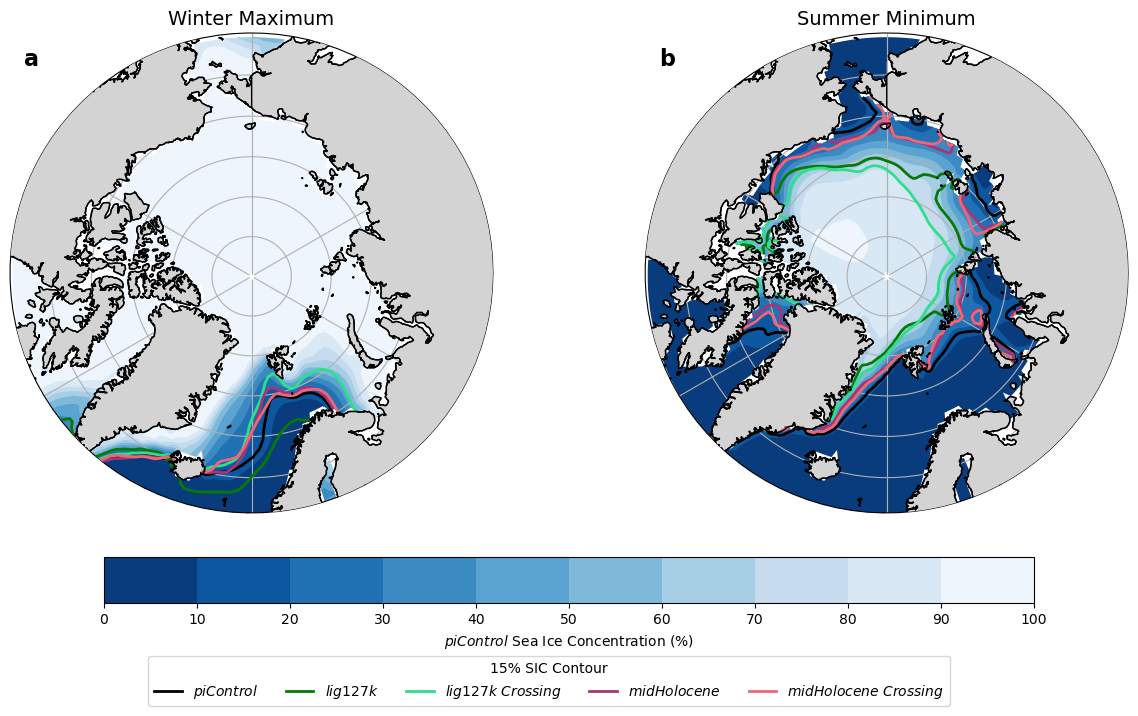

In [25]:
plot_arctic_map_contours_two_panel(
    cube_dicts=[exp_siconc_max_dict, exp_siconc_min_dict],
    titles=['Winter Maximum', 'Summer Minimum'],
    experiments=experiment_list,
    paper_colours=paper_colours
)

In [32]:

def ceil_to_5(x):
    return 5 * np.ceil(x / 5)


def plot_arctic_map_differences_two_panel(
    cube_pairs,
    titles,
    cmap='RdBu_r',
    cbar_labels=None,
    tick_step=5,
    figsize=(16, 8),
    panel_labels=['c','d'],
    save_name = None
):
    """
    Plot two Arctic difference maps side by side, each with its own colourbar.

    Parameters
    ----------
    cube_pairs : list of tuples
        List like [(cube1a, cube2a), (cube1b, cube2b)].
        Each panel plots cube1 - cube2.
    titles : list of str
        Titles for each panel.
    cmap : str, optional
        Colormap name. Default is 'RdBu_r'.
    cbar_labels : list of str, optional
        Colourbar label for each panel.
        If None, defaults to 'Sea ice concentration difference (%)'.
    tick_step : int or float, optional
        Step between colourbar ticks. Default is 5.
    figsize : tuple, optional
        Figure size.
    """

    n_panels = len(cube_pairs)

    if cbar_labels is None:
        cbar_labels = ['Sea Ice Concentration Difference (%)'] * n_panels

    fig, axes = plt.subplots(
        1, n_panels,
        figsize=figsize,
        subplot_kw={'projection': ccrs.NorthPolarStereo()}
    )

    # If only one panel were ever passed, make axes iterable
    if n_panels == 1:
        axes = [axes]

    # Circular boundary
    theta = np.linspace(0, 2 * np.pi, 100)
    x = 0.5 + 0.5 * np.cos(theta)
    y = 0.5 + 0.5 * np.sin(theta)
    circle_path = mpath.Path(np.column_stack([x, y]))

    

    for ax, (cube1, cube2), title, cbar_label, panel_label in zip(
        axes, cube_pairs, titles, cbar_labels, panel_labels
    ):
        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(circle_path, transform=ax.transAxes)

        plot_cube = cube1 - cube2
        data = np.ma.masked_invalid(plot_cube.data)

        # Symmetric limits about zero, rounded outwards to nearest 5
        max_abs = np.ma.max(np.ma.abs(data))
        max_abs = float(ceil_to_5(max_abs))

        this_vmin = -max_abs
        this_vmax = max_abs
        if max_abs > 5* tick_step:
            tick_step_use = 2 * tick_step
        else:
            tick_step_use = tick_step
        # Force contour levels and colourbar ticks to multiples of 5
        levels = np.arange(this_vmin - tick_step_use + tick_step, this_vmax + tick_step_use, tick_step_use)
        ticks = np.arange(this_vmin - tick_step_use + tick_step, this_vmax + tick_step_use, tick_step_use)

        # Ensure 0 is exactly at the centre of the colour scale
        norm = colors.TwoSlopeNorm(
            vmin=this_vmin,
            vcenter=0,
            vmax=this_vmax
        )

        plt.sca(ax)
        cf = iplt.contourf(
            plot_cube,
            levels=levels,
            cmap=cmap,
            norm=norm,
            extend='both'
        )

        ax.set_title(title, fontsize=14)

        ax.coastlines(zorder=5)
        ax.add_feature(
            cfeature.LAND,
            zorder=3,
            edgecolor='k',
            facecolor='lightgray'
        )
        ax.gridlines()

        # Panel letter
        ax.text(
            0.03, 0.97,
            panel_label,
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=16,
            fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
        )

        # Individual colourbar
        cbar = fig.colorbar(
            cf,
            ax=ax,
            orientation='horizontal',
            pad=0.06,
            shrink=0.8,
            ticks=ticks
        )
        cbar.set_label(cbar_label)

    plt.subplots_adjust(
        bottom=0.12,
        wspace=0.18
    )
    if save_name is not None:
        fig.savefig(
        f'/home/users/matt/FutureComparisons/Figures/{save_name}',
        bbox_inches="tight"
)
    plt.show()

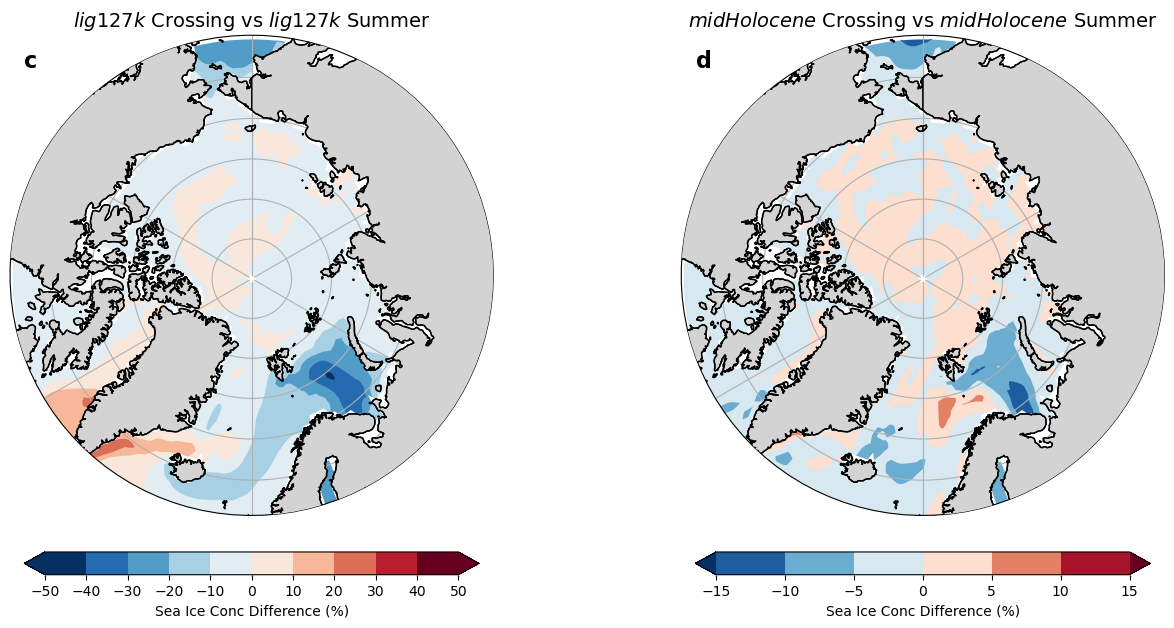

In [ ]:
plot_arctic_map_differences_two_panel(
    cube_pairs=[
        (
            exp_siconc_max_dict[f'{paleo} Crossing']['MMM'],
            exp_siconc_max_dict[paleo]['MMM']
        ),
        (
            exp_siconc_max_dict[f'{paleo2} Crossing']['MMM'],
            exp_siconc_max_dict[paleo2]['MMM']
        ),
    ],
    titles=[
        r'$\mathit{{lig127k}}$ Crossing vs $\mathit{{lig127k}}$ Summer',
        r'$\mathit{{midHolocene}}$ Crossing vs $\mathit{{midHolocene}}$ Summer'
    ],
    cmap='RdBu_r',
    cbar_labels=[
        'Sea Ice Concentration Difference (%)',
        'Sea Ice Concentration Difference (%)'
    ],
    save_name = 'map_cross_paleo_diff.png'
)